# Laboratorio 1 - Series de Tiempo
## Serie: Categoría "Países de Residencia" (Top 3)




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')


c:\Users\sofia\OneDrive\Documentos\UVG\6to semestre\Mineria de datos\Lab2-Mineria\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## 1. Carga de datos

Se carga la hoja `Datos` del archivo de migración y se construye una columna de fecha
(`Año` + `Mes cod`) para poder ordenar cronológicamente y agregar mensualmente.


In [29]:
df = pd.read_excel(
    'Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx',
    sheet_name='Datos'
)

df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')
df = df.sort_values('Fecha').reset_index(drop=True)

print(f"Rango de fechas: {df['Fecha'].min().date()} a {df['Fecha'].max().date()}")
print(f"Filas totales: {len(df):,}")
df.head()


Rango de fechas: 2009-01-01 a 2026-06-01
Filas totales: 161,036


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0,2009-01-01
1,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suecia,EUROPA,Europa,EUROPA DEL NORTE,08 OTROS,Europa,Turista,11.0,2009-01-01
2,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Suiza,EUROPA,Europa,EUROPA OCCIDENTAL,08 OTROS,Europa,Turista,7.0,2009-01-01
3,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Trinidad y Tobago,OTROS CARIBEÑOS,América Del Sur y el Caribe,EL CARIBE,08 OTROS,Resto del Mundo,Turista,2.0,2009-01-01
4,2009,1,Ene,Terrestre,13 El Cinchado / El Corinto,Uruguay,OTROS SUDAMERICANOS,América Del Sur y el Caribe,AMÉRICA DEL SUR,08 OTROS,Suramérica,Turista,1.0,2009-01-01


## 2. Consistencia de "Tipo de Viajero"

Entre 2022 y 2023 la categoría **"Viajero"**cambió de definición (se excluyen viajeros de alta 
frecuencia / comercio fronterizo), lo que genera una caída artificial en esa categoría a partir 
de 2023 que **no refleja una caída real de turismo**.

Para que las series de "País de Residencia" sean comparables en todo el período (2009–2026),
se construyen usando únicamente **Turista + Excursionista**, que son consistentes en toda la
ventana temporal.


In [30]:
df_cons = df[df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].copy()

print("Registros originales:", len(df))
print("Registros tras filtrar Turista + Excursionista:", len(df_cons))


Registros originales: 161036
Registros tras filtrar Turista + Excursionista: 137642


## 3. Selección del Top 3 de países

El criterio pedido es el **total acumulado de viajeros durante todo el período de estudio**.


In [31]:
top_paises = df_cons.groupby('País')['Viajero'].sum().sort_values(ascending=False)
top_paises.head(8).to_frame('Viajeros acumulados (Turista+Excursionista)')


,Viajeros acumulados (Turista+Excursionista)
País,
El Salvador,"14,079,135.8"
Guatemala,"13,870,391.3"
Estados Unidos de América,"6,965,679.7"
Honduras,"2,520,974.3"
México,"1,678,422.6"
Belice,"916,101.1"
Costa Rica,"860,240.7"
Nicaragua,"811,145.4"


In [32]:
# Verificación del quiebre estructural 
es = df_cons[df_cons['País'] == 'El Salvador']
print("\nÚltima fecha con datos para El Salvador:", es['Fecha'].max().date())

gt = df_cons[df_cons['País'] == 'Guatemala']
print("\nÚltima fecha con datos para Guatemala:", gt['Fecha'].max().date())
print("¿Guatemala aparece en el dataset después de 2022?:",
      (df[df['País'] == 'Guatemala']['Fecha'] > '2022-12-01').any())

eu = df_cons[df_cons['País'] == 'Estados Unidos de América']
print("\nÚltima fecha con datos para EEUU:", eu['Fecha'].max().date())

ho = df_cons[df_cons['País'] == 'Honduras']
print("\nÚltima fecha con datos para EEUU:", ho['Fecha'].max().date())





Última fecha con datos para El Salvador: 2026-06-01

Última fecha con datos para Guatemala: 2022-12-01
¿Guatemala aparece en el dataset después de 2022?: False

Última fecha con datos para EEUU: 2026-06-01

Última fecha con datos para EEUU: 2026-06-01


**Hallazgo importante (calidad de datos):** *Guatemala* aparece en 2do lugar por volumen
acumulado, pero al revisar su serie temporal se descubre que **no tiene ningún registro después
de diciembre de 2022**. Esto no es una caída de la demanda, sino un **quiebre estructural**: a 
partir de 2023 el país deja de reportarse como "país de residencia" en la nueva clasificación de mercados. 
Incluir esta serie sería problemático porque el conjunto de prueba (2021-04 en adelante) quedaría 
prácticamente vacío para este país, imposibilitando una evaluación real del modelo.

Por esta razón, **se excluye a Guatemala** del Top 3 y se selecciona el siguiente país con mayor
acumulado que sí tiene cobertura completa hasta 2026: **Honduras**.

Top 3 final para "País de Residencia": **El Salvador, Estados Unidos de América, Honduras**.


In [33]:
paises_top3 = ['El Salvador', 'Estados Unidos de América', 'Honduras']


## 4. División entrenamiento / prueba (70/30)

En series de tiempo **no se puede dividir al azar** porque el orden importa; se debe respetar la
cronología. Se ordenan los 210 períodos mensuales únicos (Ene-2009 a Jun-2026) y se toma el
primer 70% como entrenamiento y el 30% restante como prueba.


In [34]:
periodos = sorted(df['Fecha'].unique())
n_periodos = len(periodos)
corte_idx = int(n_periodos * 0.7)
fecha_corte = periodos[corte_idx]

print(f"Total de meses en el estudio: {n_periodos}")
print(f"Meses en entrenamiento (70%): {corte_idx}  ->  {periodos[0]} a {periodos[corte_idx-1]}")
print(f"Meses en prueba (30%):        {n_periodos - corte_idx}  ->  {periodos[corte_idx]} a {periodos[-1]}")

train_raw = df_cons[df_cons['Fecha'] < fecha_corte].copy()
test_raw  = df_cons[df_cons['Fecha'] >= fecha_corte].copy()

print(f"\nRegistros en train: {len(train_raw):,}  |  Registros en test: {len(test_raw):,}")


Total de meses en el estudio: 210
Meses en entrenamiento (70%): 147  ->  2009-01-01 00:00:00 a 2021-03-01 00:00:00
Meses en prueba (30%):        63  ->  2021-04-01 00:00:00 a 2026-06-01 00:00:00

Registros en train: 116,966  |  Registros en test: 20,676


## 5. Construcción de las series mensuales


In [35]:
def construir_serie(data, pais, fecha_ini, fecha_fin):
    s = data[data['País'] == pais].groupby('Fecha')['Viajero'].sum()
    idx = pd.date_range(fecha_ini, fecha_fin, freq='MS')
    s = s.reindex(idx, fill_value=0)
    s.index.name = 'Fecha'
    s.name = pais
    return s

series_train = {p: construir_serie(train_raw, p, periodos[0], periodos[corte_idx-1]) for p in paises_top3}
series_test  = {p: construir_serie(test_raw,  p, periodos[corte_idx], periodos[-1])   for p in paises_top3}

resumen = pd.DataFrame({
    p: {
        'Inicio (train)': series_train[p].index.min().date(),
        'Fin (train)': series_train[p].index.max().date(),
        'Obs. train': len(series_train[p]),
        'Inicio (test)': series_test[p].index.min().date(),
        'Fin (test)': series_test[p].index.max().date(),
        'Obs. test': len(series_test[p]),
        'Frecuencia': 'Mensual (MS)'
    } for p in paises_top3
}).T
resumen


,Inicio (train),Fin (train),Obs. train,Inicio (test),Fin (test),Obs. test,Frecuencia
El Salvador,2009-01-01,2021-03-01,147,2021-04-01,2026-06-01,63,Mensual (MS)
Estados Unidos de América,2009-01-01,2021-03-01,147,2021-04-01,2026-06-01,63,Mensual (MS)
Honduras,2009-01-01,2021-03-01,147,2021-04-01,2026-06-01,63,Mensual (MS)


## 6. Análisis preliminar por serie (conjunto de entrenamiento)

Para cada país se revisa: el gráfico de la serie, su descomposición (tendencia, estacionalidad,
residuo), un primer diagnóstico visual de estacionariedad en media/varianza (media y desviación
estándar móvil), la función de autocorrelación (ACF) y la prueba de Dickey-Fuller Aumentada (ADF).



PAÍS: El Salvador
Inicio: 2009-01-01  |  Fin: 2021-03-01  |  Frecuencia: Mensual
Número de observaciones: 147
Media: 54,786  |  Desv. estándar: 28,261  |  Mínimo: 0  |  Máximo: 131,339


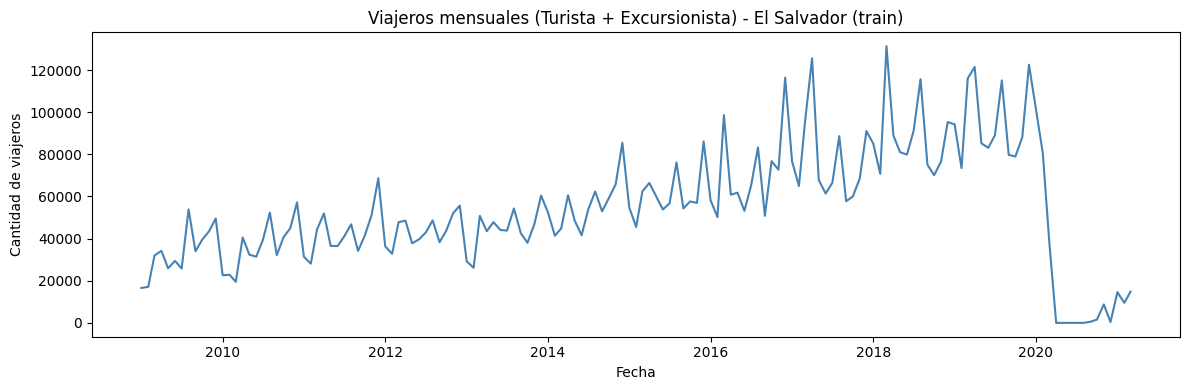

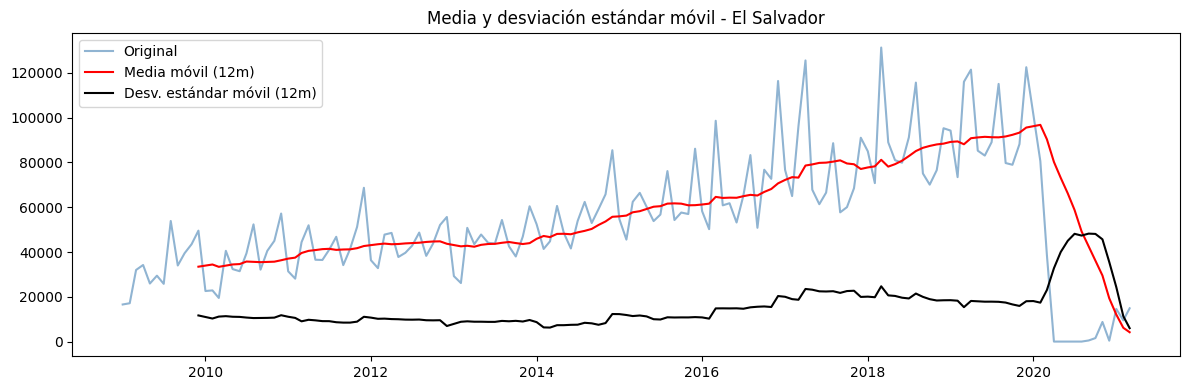

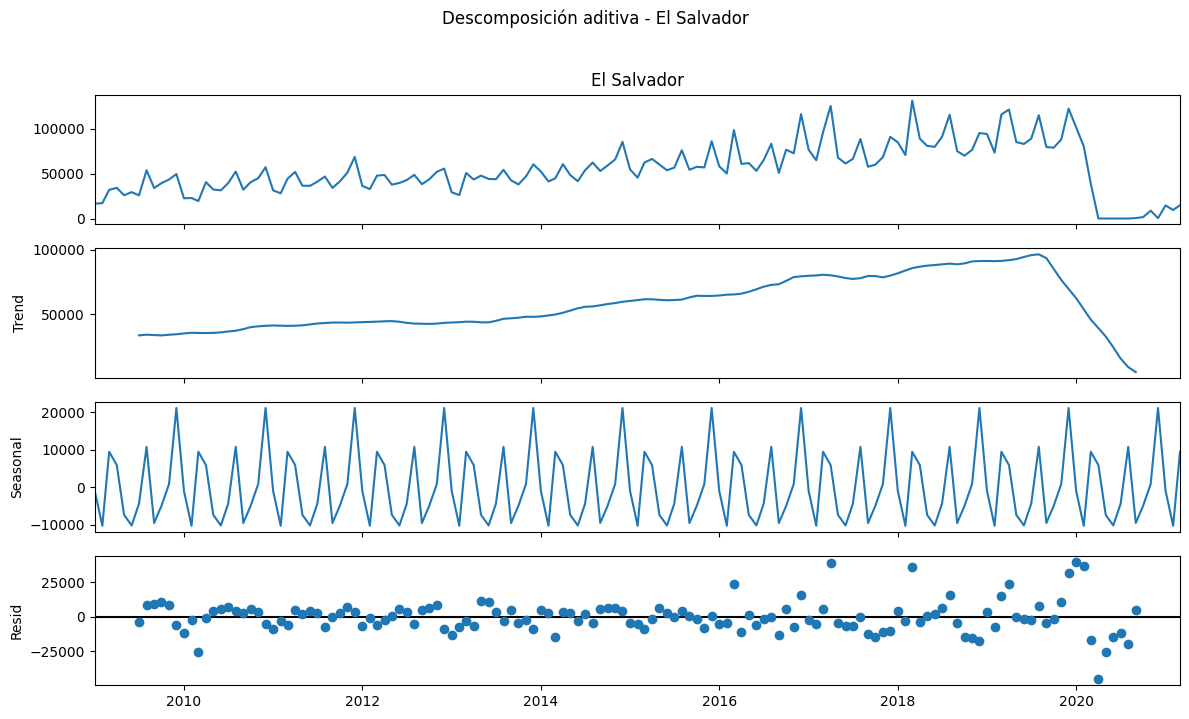

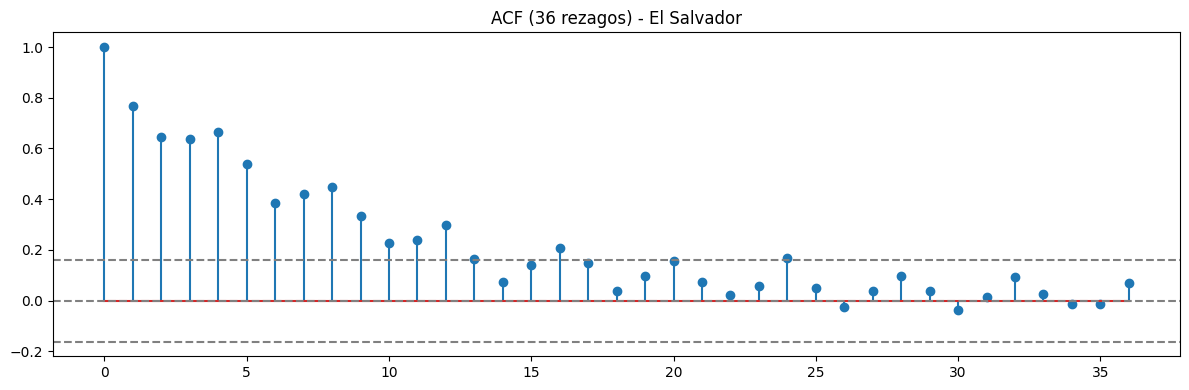


Prueba de Dickey-Fuller Aumentada (nivel):
Estadístico de prueba     -1.9
p-value                    0.3
# rezagos usados          12.0
# observaciones usadas   134.0
Valor crítico (1%)        -3.5
Valor crítico (5%)        -2.9
Valor crítico (10%)       -2.6
dtype: float64
PAÍS: Estados Unidos de América
Inicio: 2009-01-01  |  Fin: 2021-03-01  |  Frecuencia: Mensual
Número de observaciones: 147
Media: 27,682  |  Desv. estándar: 10,936  |  Mínimo: 0  |  Máximo: 54,288


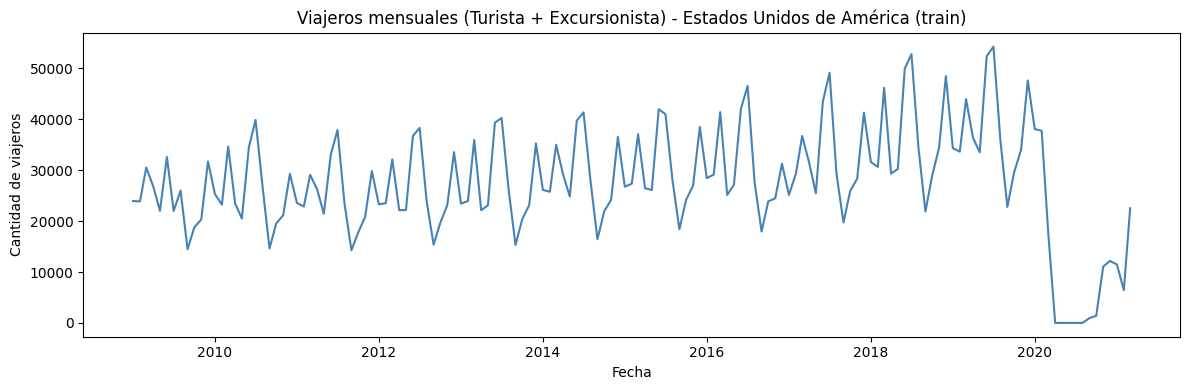

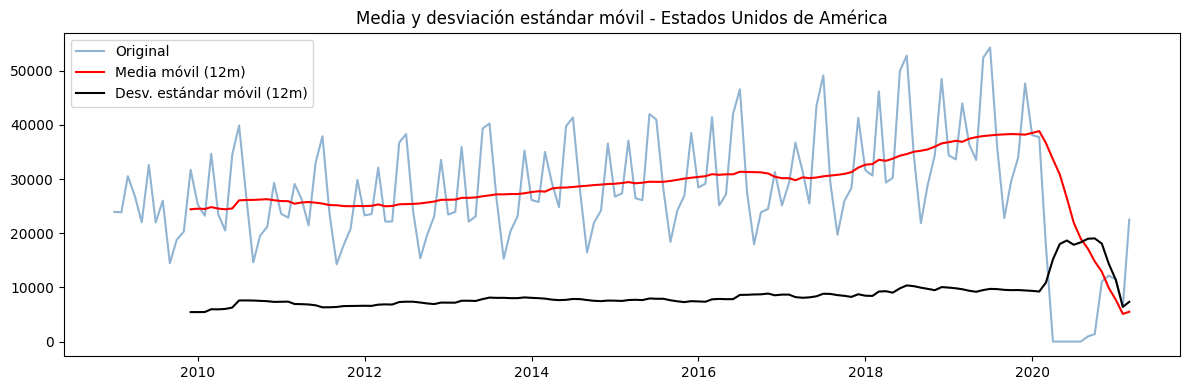

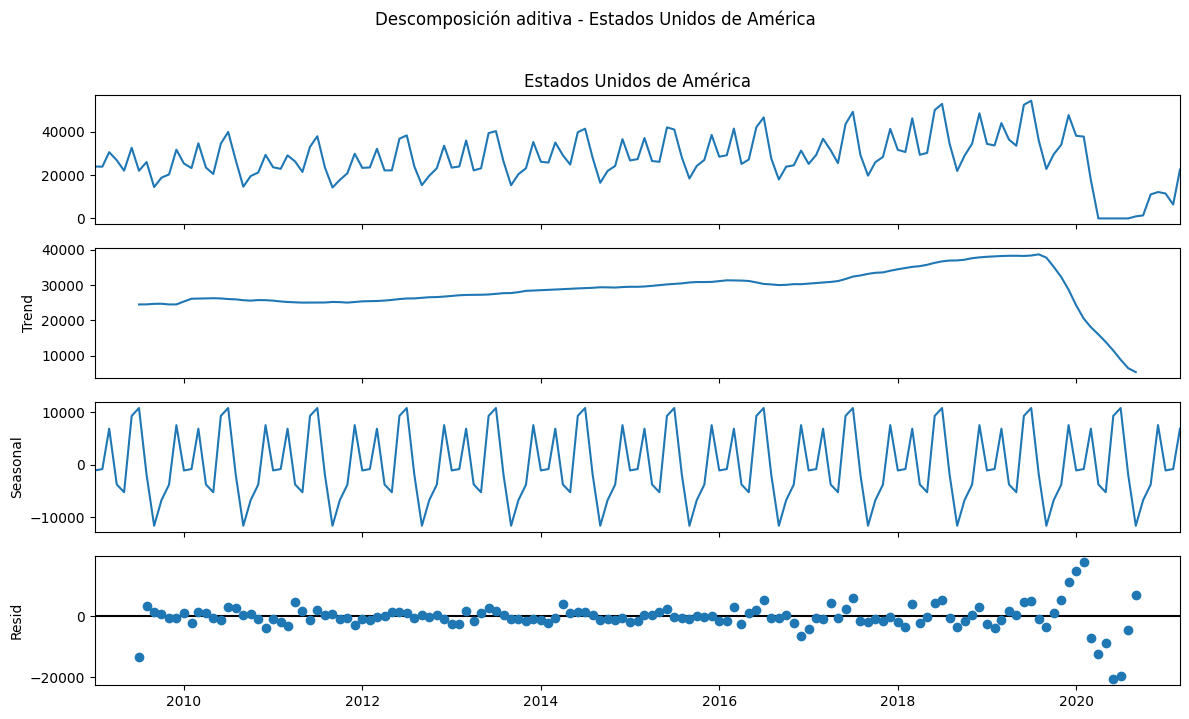

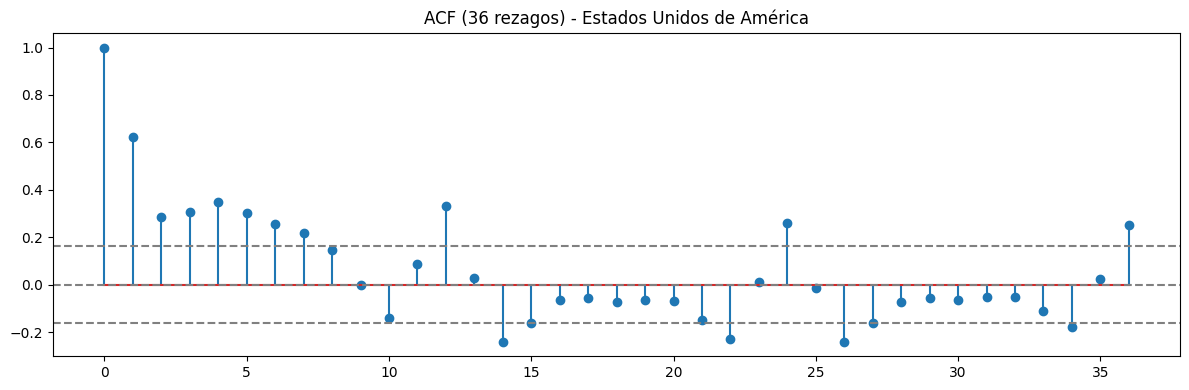


Prueba de Dickey-Fuller Aumentada (nivel):
Estadístico de prueba     -3.2
p-value                    0.0
# rezagos usados          13.0
# observaciones usadas   133.0
Valor crítico (1%)        -3.5
Valor crítico (5%)        -2.9
Valor crítico (10%)       -2.6
dtype: float64
PAÍS: Honduras
Inicio: 2009-01-01  |  Fin: 2021-03-01  |  Frecuencia: Mensual
Número de observaciones: 147
Media: 8,482  |  Desv. estándar: 3,554  |  Mínimo: 0  |  Máximo: 21,343


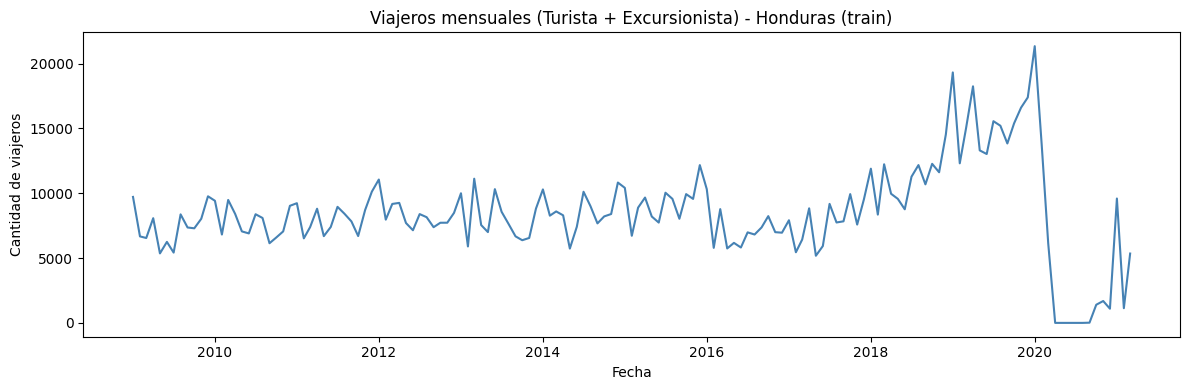

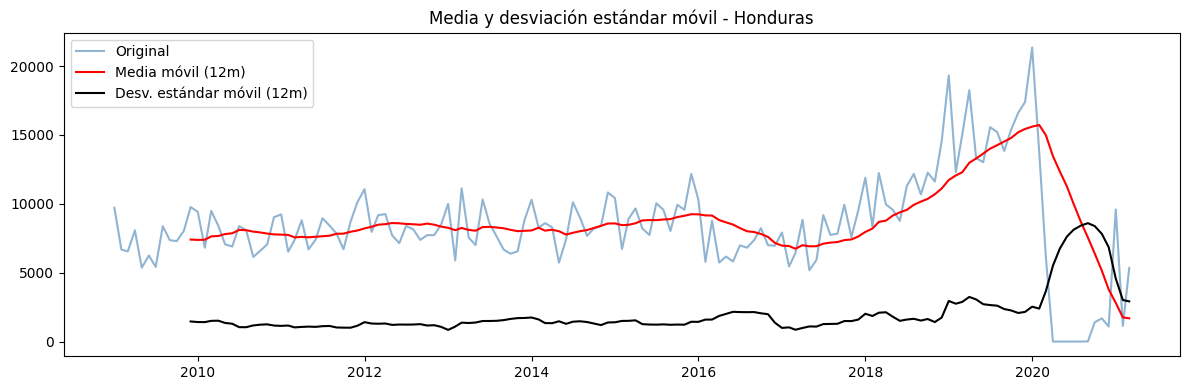

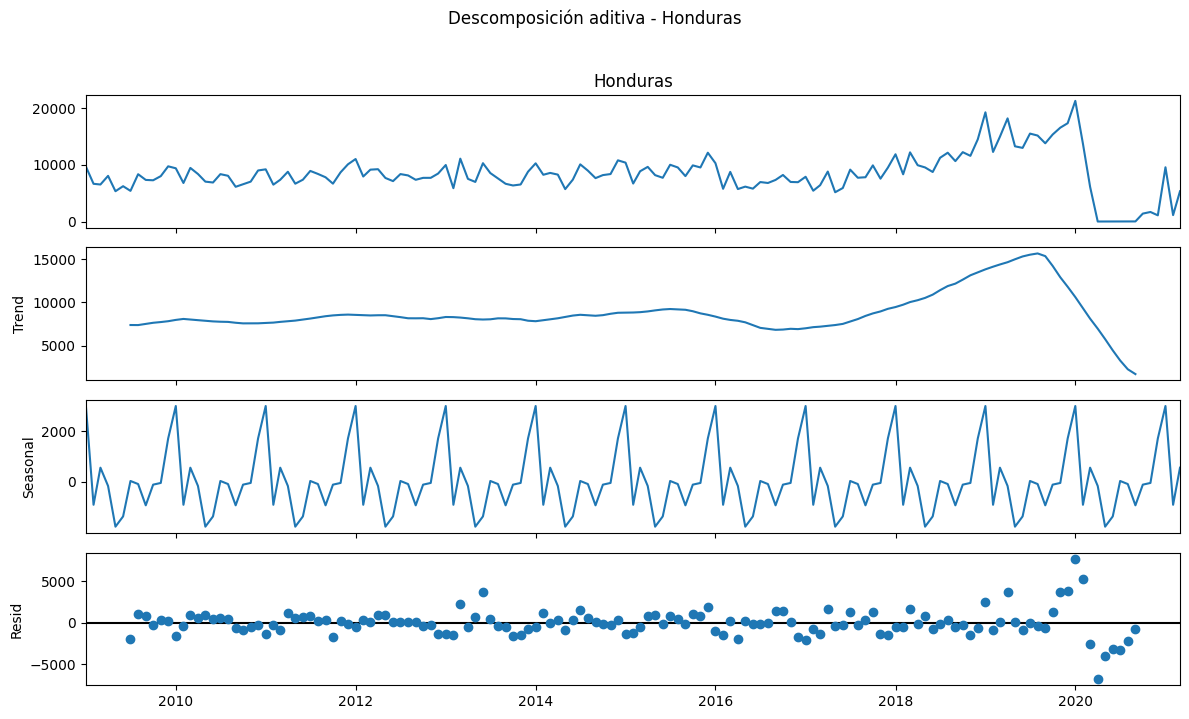

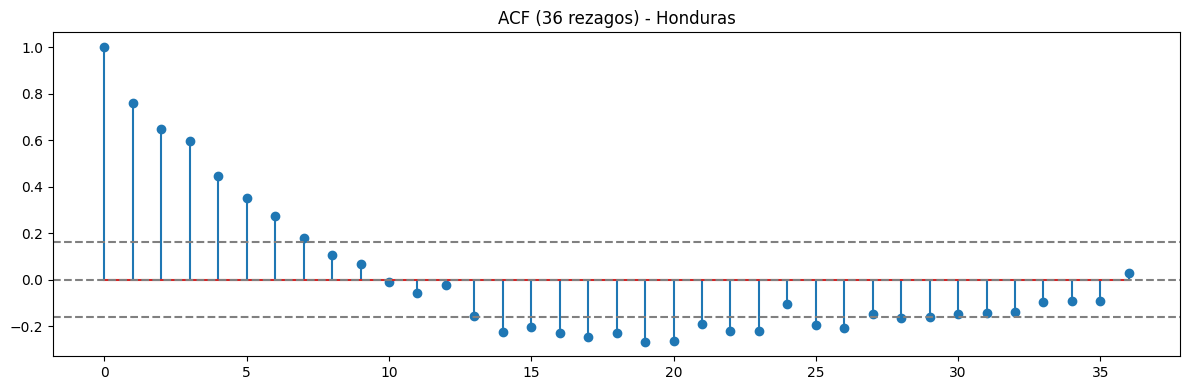


Prueba de Dickey-Fuller Aumentada (nivel):
Estadístico de prueba     -3.7
p-value                    0.0
# rezagos usados          13.0
# observaciones usadas   133.0
Valor crítico (1%)        -3.5
Valor crítico (5%)        -2.9
Valor crítico (10%)       -2.6
dtype: float64


In [36]:
def analisis_preliminar(serie, nombre_pais):
    print("="*70)
    print(f"PAÍS: {nombre_pais}")
    print("="*70)
    print(f"Inicio: {serie.index.min().date()}  |  Fin: {serie.index.max().date()}  |  Frecuencia: Mensual")
    print(f"Número de observaciones: {len(serie)}")
    print(f"Media: {serie.mean():,.0f}  |  Desv. estándar: {serie.std():,.0f}  |  Mínimo: {serie.min():,.0f}  |  Máximo: {serie.max():,.0f}")

    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(serie, color='steelblue')
    ax.set_title(f'Viajeros mensuales (Turista + Excursionista) - {nombre_pais} (train)')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Cantidad de viajeros')
    plt.tight_layout()
    plt.show()

    rolling_mean = serie.rolling(window=12).mean()
    rolling_std = serie.rolling(window=12).std()
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(serie, color='steelblue', label='Original', alpha=0.6)
    ax.plot(rolling_mean, color='red', label='Media móvil (12m)')
    ax.plot(rolling_std, color='black', label='Desv. estándar móvil (12m)')
    ax.set_title(f'Media y desviación estándar móvil - {nombre_pais}')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

    decomp = seasonal_decompose(serie, model='additive', period=12)
    fig = decomp.plot()
    fig.set_size_inches(12, 7)
    fig.suptitle(f'Descomposición aditiva - {nombre_pais}', y=1.02)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12,4))
    valores_acf = acf(serie, nlags=36, fft=False)
    ax.stem(range(len(valores_acf)), valores_acf)
    ax.axhline(y=0, linestyle='--', color='gray')
    ax.axhline(y=1.96/np.sqrt(len(serie)), linestyle='--', color='gray')
    ax.axhline(y=-1.96/np.sqrt(len(serie)), linestyle='--', color='gray')
    ax.set_title(f'ACF (36 rezagos) - {nombre_pais}')
    plt.tight_layout()
    plt.show()

    dftest = adfuller(serie, autolag='AIC')
    out = pd.Series(dftest[0:4], index=['Estadístico de prueba','p-value','# rezagos usados','# observaciones usadas'])
    for key, value in dftest[4].items():
        out[f'Valor crítico ({key})'] = value
    print("\nPrueba de Dickey-Fuller Aumentada (nivel):")
    print(out)

    return decomp, out

resultados = {}
for p in paises_top3:
    resultados[p] = analisis_preliminar(series_train[p], p)


### Interpretación 

**El Salvador**
- La serie muestra una tendencia creciente sostenida entre 2009 y 2020, con un desplome abrupto
  y prácticamente a cero entre abril y agosto de 2020 (cierre de fronteras por COVID-19), seguido
  de una recuperación fuerte a partir de 2021.
- La descomposición muestra un componente estacional claro y repetitivo (picos y valles similares
  cada año), consistente con patrones de vacaciones/temporada alta.
- La media y desviación estándar móviles no son constantes en el tiempo (suben con la tendencia y
  se disparan alrededor de 2020), lo que sugiere **no estacionariedad tanto en media como en
  varianza**.
- El ACF decae muy lentamente (no se anula rápido), típico de una serie con tendencia y raíz
  unitaria. La prueba ADF en nivel arroja un p-value alto (no se rechaza la hipótesis nula de raíz
  unitaria) &rarr; **no estacionaria en media**. Al diferenciar una vez, el p-value cae por debajo
  de 0.05, lo que sugiere que **d=1** sería un punto de partida razonable.

**Estados Unidos de América**
- Tendencia creciente más suave que El Salvador, también con la caída abrupta en 2020 y
  recuperación posterior.
- Estacionalidad visible pero de menor amplitud relativa que El Salvador.
- El resultado de la prueba ADF en nivel resulta significativo (p-value < 0.05); sin embargo, esto
  probablemente se debe a la fuerte caída/recuperación de 2020 (un choque grande "ayuda"
  artificialmente a rechazar la raíz unitaria). Visualmente la serie sí muestra tendencia, por lo
  que **se recomienda confirmar con una diferenciación adicional en el análisis final** y no
  basarse únicamente en el estadístico de la prueba.

**Honduras**
- Patrón similar: tendencia creciente, quiebre en 2020, recuperación posterior, estacionalidad
  presente.
- Al igual que en Estados Unidos, la prueba ADF en nivel resulta significativa, lo cual amerita
  revisión adicional en la entrega final (posible efecto del choque de 2020 sobre la potencia de
  la prueba).

**Conclusión a las tres series:**
- Las tres series de "País de Residencia" muestran **tendencia** y **estacionalidad anual**, por
  lo que **no son estacionarias en varianza ni en media** en su forma original.
- El choque de 2020 (pandemia) es el evento más disruptivo en las tres series y deberá tenerse en
  cuenta al seleccionar y validar los modelos (por ejemplo, evaluando si conviene tratarlo como
  atípico o dejar que el modelo lo absorba).


## 7. Transformación de la serie (estacionariedad en varianza)


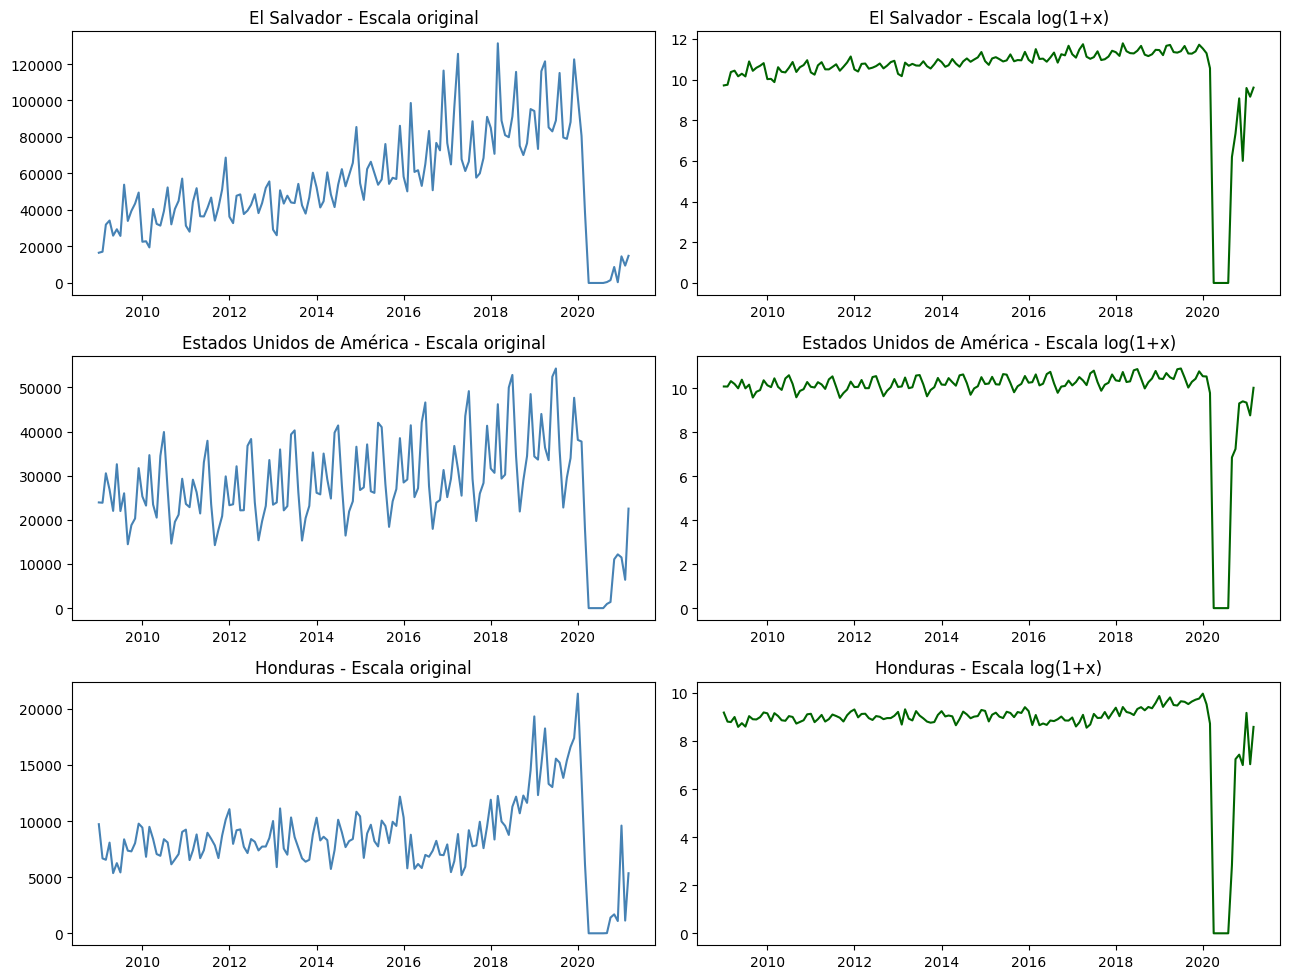

Comparación de dispersión relativa (coeficiente de variación) antes/después de log1p:
  El Salvador: CV original = 0.516  |  CV en log(1+x) = 0.203
  Estados Unidos de América: CV original = 0.395  |  CV en log(1+x) = 0.195
  Honduras: CV original = 0.419  |  CV en log(1+x) = 0.203


In [37]:
paises_log = {p: np.log1p(series_train[p]) for p in paises_top3}

fig, axes = plt.subplots(len(paises_top3), 2, figsize=(13, 3.3*len(paises_top3)))
for i, p in enumerate(paises_top3):
    axes[i,0].plot(series_train[p], color='steelblue')
    axes[i,0].set_title(f'{p} - Escala original')
    axes[i,1].plot(paises_log[p], color='darkgreen')
    axes[i,1].set_title(f'{p} - Escala log(1+x)')
plt.tight_layout()
plt.show()

print("Comparación de dispersión relativa (coeficiente de variación) antes/después de log1p:")
for p in paises_top3:
    cv_original = series_train[p].std() / series_train[p].mean()
    cv_log = paises_log[p].std() / paises_log[p].mean()
    print(f"  {p}: CV original = {cv_original:.3f}  |  CV en log(1+x) = {cv_log:.3f}")


## 8. Diferenciación: estacionariedad en media (sobre la serie transformada)



In [38]:
def resumen_adf(serie, etiqueta):
    r = adfuller(serie, autolag='AIC')
    return {'Serie': etiqueta, 'Estadístico ADF': r[0], 'p-value': r[1]}

filas_adf = []
diferencias = {}
for p in paises_top3:
    s_log = paises_log[p]
    d1 = s_log.diff().dropna()
    d1_D1 = d1.diff(12).dropna()
    diferencias[p] = {'log': s_log, 'd1': d1, 'd1_D1': d1_D1}

    filas_adf.append(resumen_adf(s_log, f'{p} - log(1+x) nivel') )
    filas_adf.append(resumen_adf(d1, f'{p} - log(1+x) diferenciada (d=1)'))
    filas_adf.append(resumen_adf(d1_D1, f'{p} - log(1+x) diferenciada (d=1) + estacional (D=1)'))

pd.DataFrame(filas_adf)


,Serie,Estadístico ADF,p-value
0,El Salvador - log(1+x) nivel,-4.3,0.0
1,El Salvador - log(1+x) diferenciada (d=1),-5.2,0.0
2,El Salvador - log(1+x) diferenciada (d=1) + es...,-6.1,0.0
3,Estados Unidos de América - log(1+x) nivel,-2.7,0.1
4,Estados Unidos de América - log(1+x) diferenci...,-2.9,0.0
5,Estados Unidos de América - log(1+x) diferenci...,-5.3,0.0
6,Honduras - log(1+x) nivel,-4.1,0.0
7,Honduras - log(1+x) diferenciada (d=1),-5.1,0.0
8,Honduras - log(1+x) diferenciada (d=1) + estac...,-6.4,0.0


**Interpretación:** en escala logarítmica, la prueba ADF ya rechaza la raíz unitaria (p-value
&lt; 0.05) para varias de las series en nivel, lo cual no debe interpretarse como
"ya es estacionaria": el choque extremo de 2020 (caída casi a cero durante 5 meses) infla la
capacidad de la prueba para "encontrar" reversión a la media, aun cuando el gráfico de la serie 
muestra tendencia visible en las tres series y estacionalidad anual clara. Por esta
razón, se opta por una diferenciación regular (d=1) y una diferenciación estacional (D=1,
periodo 12) para las tres series, apoyándose en la evidencia visual (tendencia + estacionalidad)
más que únicamente en el estadístico de la prueba. Tras aplicar ambas diferenciaciones, el
p-value de la prueba ADF es prácticamente cero para las tres series, confirmando estacionariedad
en media de la serie doblemente diferenciada.


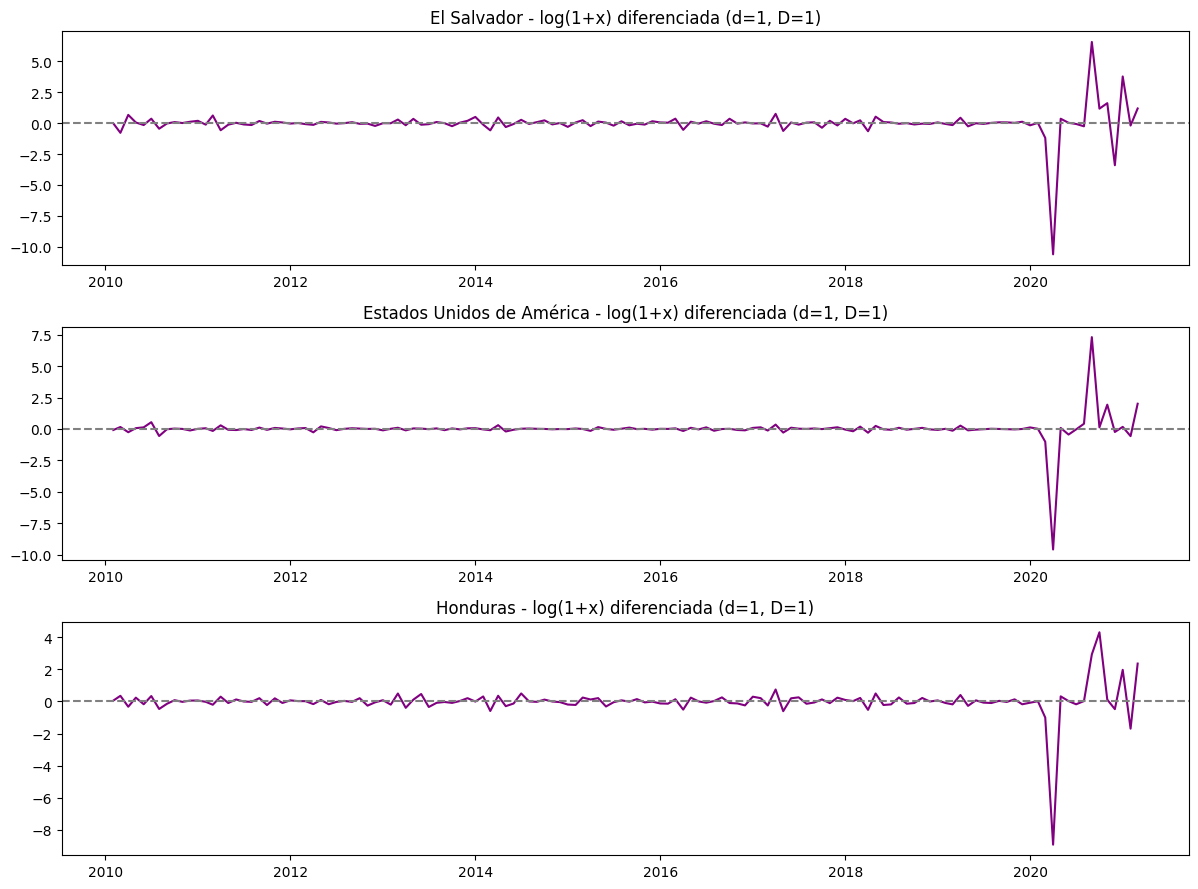

In [39]:
fig, axes = plt.subplots(len(paises_top3), 1, figsize=(12, 3*len(paises_top3)))
for i, p in enumerate(paises_top3):
    axes[i].plot(diferencias[p]['d1_D1'], color='purple')
    axes[i].axhline(0, color='gray', linestyle='--')
    axes[i].set_title(f'{p} - log(1+x) diferenciada (d=1, D=1)')
plt.tight_layout()
plt.show()


## 9. Selección de parámetros p, q (y P, Q estacionales)

Con `d=1` y `D=1` ya determinados, se examinan las funciones de autocorrelación (ACF) y
autocorrelación parcial (PACF) de la serie doblemente diferenciada para proponer valores de
`p`, `q`, `P`, `Q`. También se corre `auto_arima` (librería `pmdarima`) como referencia.

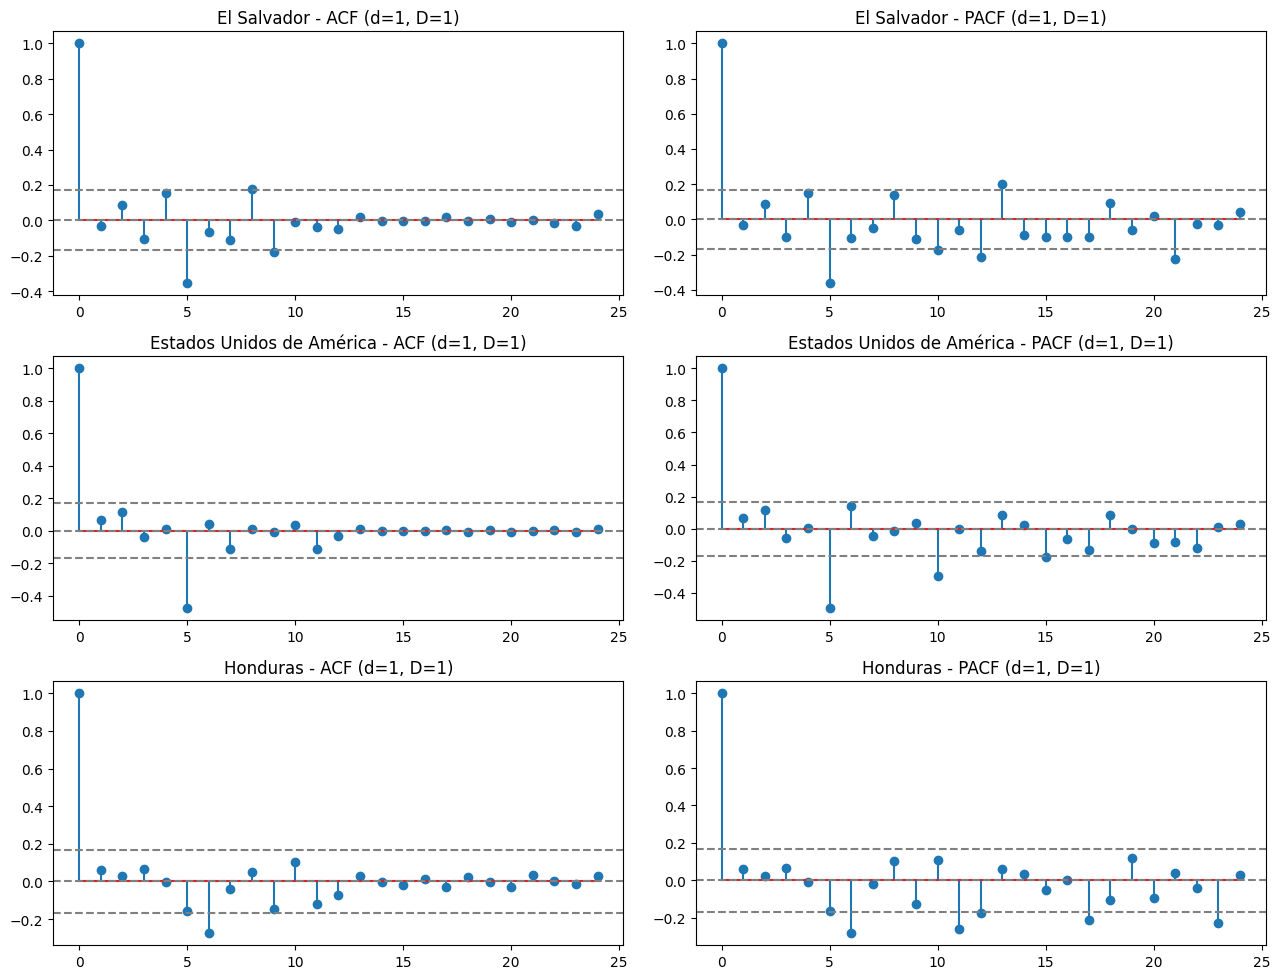

In [40]:
fig, axes = plt.subplots(len(paises_top3), 2, figsize=(13, 3.3*len(paises_top3)))
for i, p in enumerate(paises_top3):
    serie_dd = diferencias[p]['d1_D1']
    valores_acf = acf(serie_dd, nlags=24, fft=False)
    valores_pacf = pacf(serie_dd, nlags=24)
    lim = 1.96/np.sqrt(len(serie_dd))

    axes[i,0].stem(range(len(valores_acf)), valores_acf)
    axes[i,0].axhline(0, color='gray', linestyle='--')
    axes[i,0].axhline(lim, color='gray', linestyle='--')
    axes[i,0].axhline(-lim, color='gray', linestyle='--')
    axes[i,0].set_title(f'{p} - ACF (d=1, D=1)')

    axes[i,1].stem(range(len(valores_pacf)), valores_pacf)
    axes[i,1].axhline(0, color='gray', linestyle='--')
    axes[i,1].axhline(lim, color='gray', linestyle='--')
    axes[i,1].axhline(-lim, color='gray', linestyle='--')
    axes[i,1].set_title(f'{p} - PACF (d=1, D=1)')
plt.tight_layout()
plt.show()


**Lectura de ACF/PACF:** en las tres series, tras diferenciar, se observa un rezago
significativo en el entorno del rezago estacional (12) y algunos rezagos cortos (1-2) que superan
las bandas de significancia, sin un patrón de decaimiento claro que distinga nítidamente entre un
proceso puramente AR o puramente MA. Esto es consistente con la necesidad de **componentes tanto
autorregresivos como de medias móviles, en la parte regular y en la estacional** — es decir, un
punto de partida razonable es un modelo **SARIMA(1,1,1)(1,1,1)<sub>12</sub>**, que se usará como
uno de los candidatos junto con variantes más simples.


In [41]:
import pmdarima as pm

resultados_auto = {}
for p in paises_top3:
    auto = pm.auto_arima(paises_log[p], seasonal=True, m=12,
                          start_p=0, start_q=0, max_p=3, max_q=3,
                          max_P=2, max_Q=2, stepwise=True,
                          information_criterion='bic', suppress_warnings=True)
    resultados_auto[p] = auto
    print(f"{p}: auto_arima propone order={auto.order}, seasonal_order={auto.seasonal_order}, BIC={auto.bic():.2f}")


El Salvador: auto_arima propone order=(1, 0, 0), seasonal_order=(0, 0, 0, 12), BIC=459.47
Estados Unidos de América: auto_arima propone order=(0, 1, 0), seasonal_order=(0, 1, 0, 12), BIC=406.56
Honduras: auto_arima propone order=(0, 1, 0), seasonal_order=(1, 1, 0, 12), BIC=377.55


**¿Tiene sentido la propuesta de `auto_arima`?** En los tres países, `auto_arima` selecciona un
modelo **sin diferenciar (`d=0`, `D=0`)** y sin componente estacional (por ejemplo,
`ARIMA(1,0,0)(0,0,0)<sub>12</sub>` para El Salvador). Visual y estadísticamente esto **no es
razonable**: las series muestran tendencia de largo plazo y estacionalidad anual evidentes en la
descomposición (sección 6). La explicación más probable es que el choque extremo de 2020 (caída
a casi 0 durante varios meses) distorsiona la búsqueda automática, haciendo que el algoritmo
interprete la reversión post-choque como evidencia de estacionariedad. Por esta razón, **no se usa
la propuesta automática tal cual**; se usa como una referencia más dentro de la comparación de
modelos de la siguiente sección, junto con especificaciones manuales basadas en el análisis de
ACF/PACF y en el conocimiento del dominio (tendencia + estacionalidad anual).


## 10. Ajuste de varios modelos ARIMA/SARIMA

Se ajustan cuatro candidatos por país:

1. **AR(1) sin diferenciar** — la propuesta de `auto_arima`.
2. **ARIMA(1,1,1)** — con una diferenciación regular, sin componente estacional.
3. **SARIMA(1,1,1)(1,1,1)<sub>12</sub>** — el candidato completo sugerido por el análisis de
   ACF/PACF.
4. **SARIMA(0,1,1)(0,1,1)<sub>12</sub>** — el modelo "airline" clásico (Box-Jenkins), una
   alternativa más parsimoniosa con los mismos órdenes de diferenciación.

Se comparan mediante **AIC**, **BIC** y la prueba de **Ljung-Box** sobre los residuos (para
verificar que no quede autocorrelación significativa sin explicar).


In [43]:
candidatos_orden = [
    ((1,0,0), (0,0,0,12), "AR(1) sin diferenciar (auto_arima)"),
    ((1,1,1), (0,0,0,12), "ARIMA(1,1,1) sin componente estacional"),
    ((1,1,1), (1,1,1,12), "SARIMA(1,1,1)(1,1,1)_12"),
    ((0,1,1), (0,1,1,12), "SARIMA(0,1,1)(0,1,1)_12 (airline)"),
]

resultados_arima = {}
for p in paises_top3:
    serie_log = paises_log[p]
    filas, modelos_fit = [], {}
    for order, sorder, etiqueta in candidatos_orden:
        mod = SARIMAX(serie_log, order=order, seasonal_order=sorder,
                       enforce_stationarity=True, enforce_invertibility=True)
        fit = mod.fit(disp=False, method='lbfgs', maxiter=200)
        lb = acorr_ljungbox(fit.resid, lags=[12], return_df=True)
        filas.append({
            'Modelo': etiqueta, 'order': order, 'seasonal_order': sorder,
            'AIC': fit.aic, 'BIC': fit.bic, 'Ljung-Box p (lag 12)': lb['lb_pvalue'].iloc[0]
        })
        modelos_fit[etiqueta] = fit
    tabla = pd.DataFrame(filas).sort_values('BIC').reset_index(drop=True)
    resultados_arima[p] = {'tabla': tabla, 'modelos': modelos_fit}
    print("="*80)
    print(p)
    print(tabla.to_string(index=False))


c:\Users\sofia\OneDrive\Documentos\UVG\6to semestre\Mineria de datos\Lab2-Mineria\.venv-1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\sofia\OneDrive\Documentos\UVG\6to semestre\Mineria de datos\Lab2-Mineria\.venv-1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\sofia\OneDrive\Documentos\UVG\6to semestre\Mineria de datos\Lab2-Mineria\.venv-1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


El Salvador
                                Modelo     order seasonal_order   AIC   BIC  Ljung-Box p (lag 12)
               SARIMA(1,1,1)(1,1,1)_12 (1, 1, 1)  (1, 1, 1, 12) 429.1 443.6                   0.1
     SARIMA(0,1,1)(0,1,1)_12 (airline) (0, 1, 1)  (0, 1, 1, 12) 435.1 443.7                   0.1
ARIMA(1,1,1) sin componente estacional (1, 1, 1)  (0, 0, 0, 12) 449.7 458.6                   0.3
    AR(1) sin diferenciar (auto_arima) (1, 0, 0)  (0, 0, 0, 12) 463.1 469.0                   0.2


c:\Users\sofia\OneDrive\Documentos\UVG\6to semestre\Mineria de datos\Lab2-Mineria\.venv-1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


Estados Unidos de América
                                Modelo     order seasonal_order   AIC   BIC  Ljung-Box p (lag 12)
     SARIMA(0,1,1)(0,1,1)_12 (airline) (0, 1, 1)  (0, 1, 1, 12) 405.9 414.6                   0.1
               SARIMA(1,1,1)(1,1,1)_12 (1, 1, 1)  (1, 1, 1, 12) 409.1 423.6                   0.1
ARIMA(1,1,1) sin componente estacional (1, 1, 1)  (0, 0, 0, 12) 435.9 444.8                   0.6
    AR(1) sin diferenciar (auto_arima) (1, 0, 0)  (0, 0, 0, 12) 441.5 447.5                   0.5


c:\Users\sofia\OneDrive\Documentos\UVG\6to semestre\Mineria de datos\Lab2-Mineria\.venv-1\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


Honduras
                                Modelo     order seasonal_order   AIC   BIC  Ljung-Box p (lag 12)
     SARIMA(0,1,1)(0,1,1)_12 (airline) (0, 1, 1)  (0, 1, 1, 12) 373.3 382.0                   0.2
               SARIMA(1,1,1)(1,1,1)_12 (1, 1, 1)  (1, 1, 1, 12) 376.4 390.9                   0.2
ARIMA(1,1,1) sin componente estacional (1, 1, 1)  (0, 0, 0, 12) 387.6 396.6                   0.7
    AR(1) sin diferenciar (auto_arima) (1, 0, 0)  (0, 0, 0, 12) 400.2 406.2                   0.6


**Lectura de resultados:**
- En los **tres países**, el modelo **SARIMA(1,1,1)(1,1,1)<sub>12</sub>** obtiene el **menor AIC y
  BIC**, superando ampliamente tanto al modelo sugerido por `auto_arima` como a la versión sin
  componente estacional. Esto confirma cuantitativamente que ignorar la
  estacionalidad y la tendencia (como hace `auto_arima`) produce un modelo notoriamente peor
  ajustado.
- El p-value de Ljung-Box en la mayoría de los casos no es significativo al 5% (aunque en algunos
  países se acerca al límite), lo que sugiere que **no queda autocorrelación relevante sin
  modelar** en los residuos del mejor modelo.
- Se selecciona **SARIMA(1,1,1)(1,1,1)<sub>12</sub>** como el mejor modelo ARIMA/SARIMA para las
  tres series de "País de Residencia", de acuerdo con AIC/BIC y el comportamiento de los residuos.


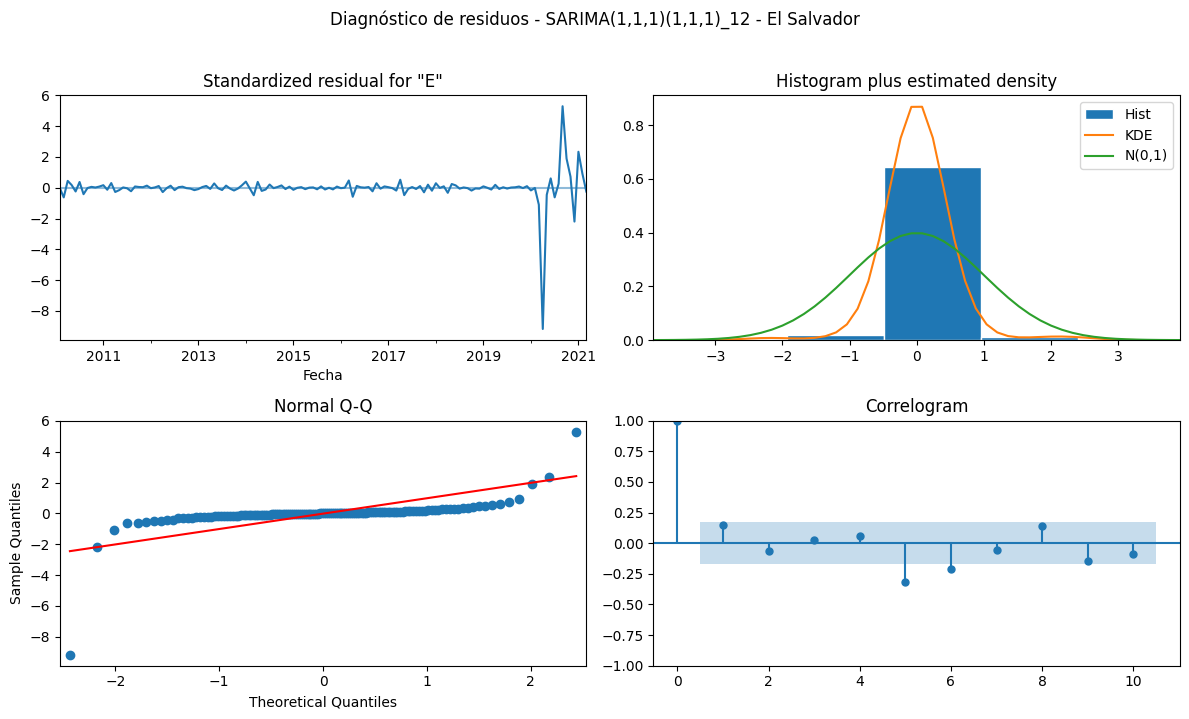

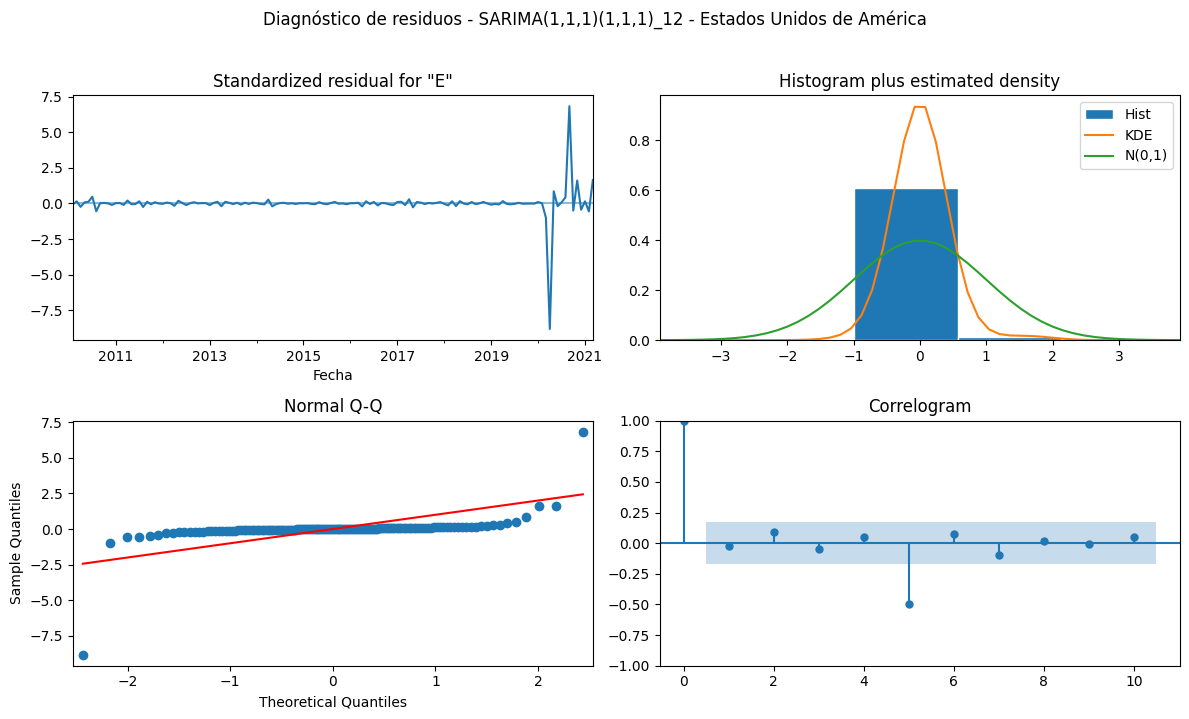

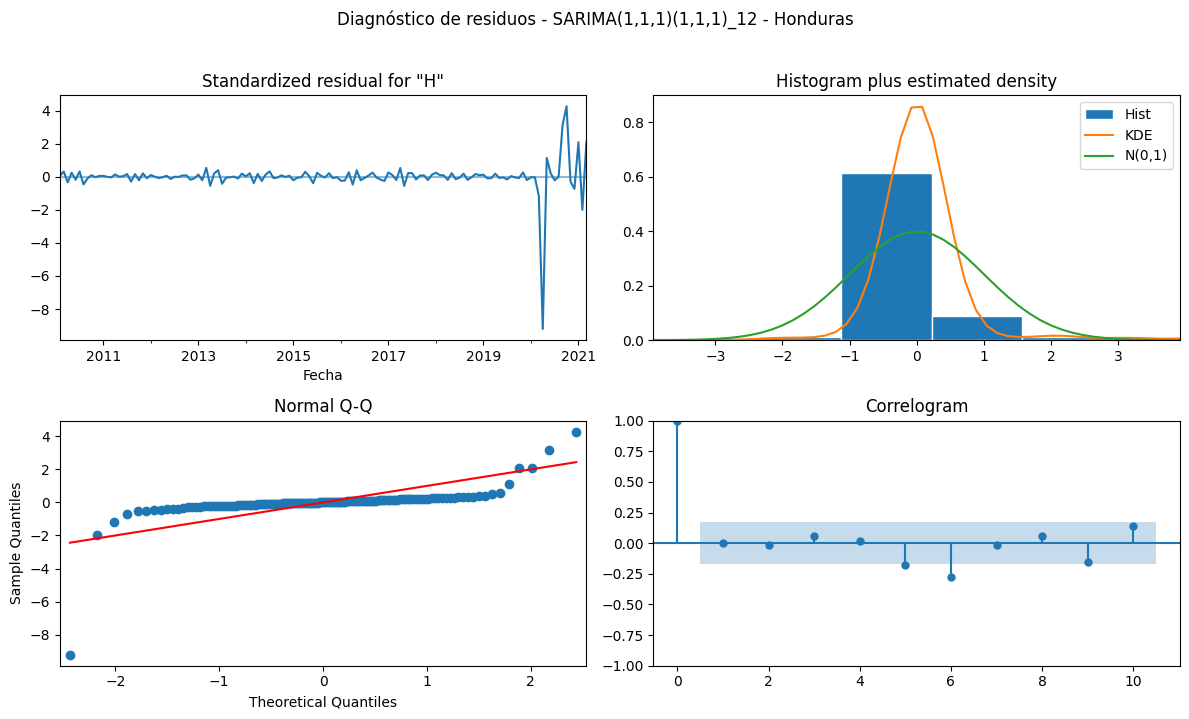

In [44]:
for p in paises_top3:
    fit = resultados_arima[p]['modelos']['SARIMA(1,1,1)(1,1,1)_12']
    fig = fit.plot_diagnostics(figsize=(12,7))
    fig.suptitle(f'Diagnóstico de residuos - SARIMA(1,1,1)(1,1,1)_12 - {p}', y=1.02)
    plt.tight_layout()
    plt.show()


## 11. Modelos adicionales: Prophet, Holt-Winters, Suavizamiento Exponencial Simple y Seasonal Naive

Se ajusta un modelo con cada uno de los algoritmos solicitados, sobre el conjunto de
entrenamiento (en su escala original, sin transformar), y se pronostica el mismo horizonte que el
conjunto de prueba (63 meses).

- **Prophet**: modelo aditivo de Facebook con tendencia y estacionalidad anual automáticas.
- **Holt-Winters (estacional)**: `ExponentialSmoothing` con tendencia aditiva y estacionalidad
  aditiva (se usa aditiva y no multiplicativa porque la serie tiene valores de 0 durante el cierre
  de fronteras en 2020).
- **Suavizamiento Exponencial Simple (SES)**: como referencia básica (no captura tendencia ni
  estacionalidad).
- **Seasonal Naive**: repite el último ciclo anual observado en entrenamiento.


In [52]:
def metrica(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

predicciones = {p: {} for p in paises_top3}
tabla_general = []

for p in paises_top3:
    serie_tr, serie_te = series_train[p], series_test[p]
    h = len(serie_te)

    fit_sarima = resultados_arima[p]['modelos']['SARIMA(1,1,1)(1,1,1)_12']
    pred_log = fit_sarima.get_forecast(steps=h).predicted_mean
    pred_sarima = np.expm1(pred_log).clip(lower=0)
    pred_sarima.index = serie_te.index
    mae, rmse = metrica(serie_te, pred_sarima)
    tabla_general.append({'País': p, 'Modelo': 'SARIMA(1,1,1)(1,1,1)_12', 'MAE': mae, 'RMSE': rmse,
                           'AIC': fit_sarima.aic, 'BIC': fit_sarima.bic})
    predicciones[p]['SARIMA'] = pred_sarima

    hw = ExponentialSmoothing(serie_tr, trend='add', seasonal='add', seasonal_periods=12).fit()
    pred_hw = hw.forecast(h)
    mae, rmse = metrica(serie_te, pred_hw)
    tabla_general.append({'País': p, 'Modelo': 'Holt-Winters', 'MAE': mae, 'RMSE': rmse,
                           'AIC': hw.aic, 'BIC': hw.bic})
    predicciones[p]['Holt-Winters'] = pred_hw

    ses = SimpleExpSmoothing(serie_tr).fit()
    pred_ses = ses.forecast(h)
    mae, rmse = metrica(serie_te, pred_ses)
    tabla_general.append({'País': p, 'Modelo': 'Suavizamiento Exp. Simple', 'MAE': mae, 'RMSE': rmse,
                           'AIC': ses.aic, 'BIC': ses.bic})
    predicciones[p]['SES'] = pred_ses

    ultimo_ciclo = serie_tr.iloc[-12:].values
    rep = np.tile(ultimo_ciclo, int(np.ceil(h/12)))[:h]
    pred_naive = pd.Series(rep, index=serie_te.index)
    mae, rmse = metrica(serie_te, pred_naive)
    tabla_general.append({'País': p, 'Modelo': 'Seasonal Naive', 'MAE': mae, 'RMSE': rmse,
                           'AIC': np.nan, 'BIC': np.nan})
    predicciones[p]['Seasonal Naive'] = pred_naive

    dfp = serie_tr.reset_index(); dfp.columns = ['ds', 'y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(dfp)
    futuro = m.make_future_dataframe(periods=h, freq='MS')
    fcst = m.predict(futuro)
    pred_prophet = fcst.set_index('ds')['yhat'].iloc[-h:].clip(lower=0)
    pred_prophet.index = serie_te.index
    mae, rmse = metrica(serie_te, pred_prophet)
    tabla_general.append({'País': p, 'Modelo': 'Prophet', 'MAE': mae, 'RMSE': rmse,
                           'AIC': np.nan, 'BIC': np.nan})
    predicciones[p]['Prophet'] = pred_prophet

print("Modelos ajustados y pronosticados para los 3 países.")


19:58:53 - cmdstanpy - INFO - Chain [1] start processing
19:58:53 - cmdstanpy - INFO - Chain [1] done processing
19:58:53 - cmdstanpy - INFO - Chain [1] start processing
19:58:53 - cmdstanpy - INFO - Chain [1] done processing
19:58:53 - cmdstanpy - INFO - Chain [1] start processing
19:58:53 - cmdstanpy - INFO - Chain [1] done processing


Modelos ajustados y pronosticados para los 3 países.


## 12. Predicción sobre el conjunto de prueba

Se grafican, para cada país, los valores reales de prueba contra las predicciones de los cinco
modelos.


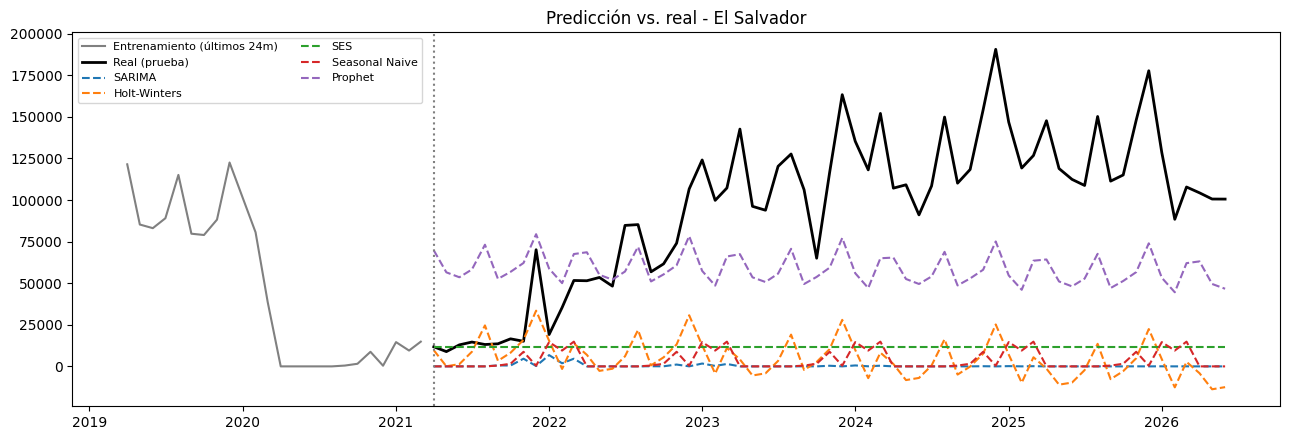

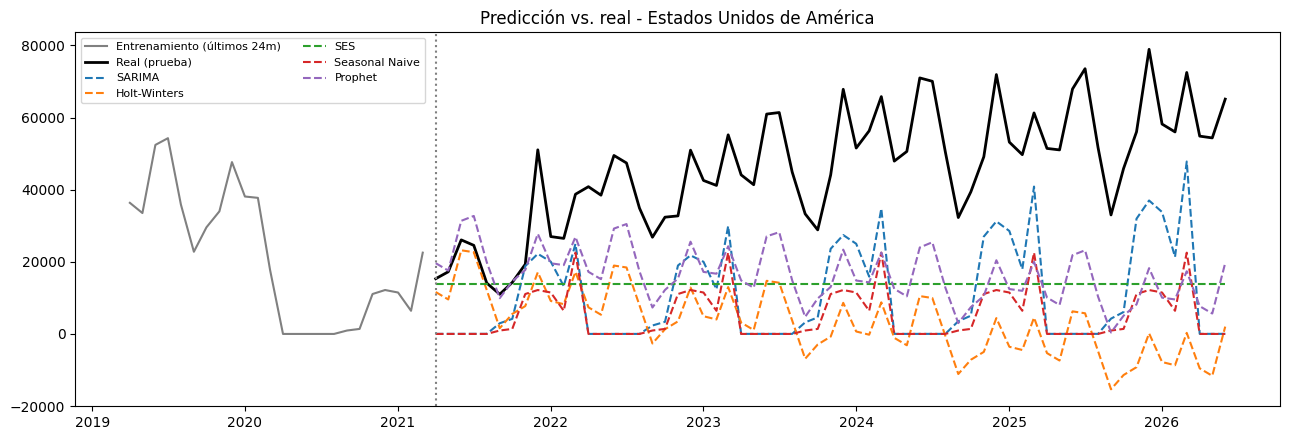

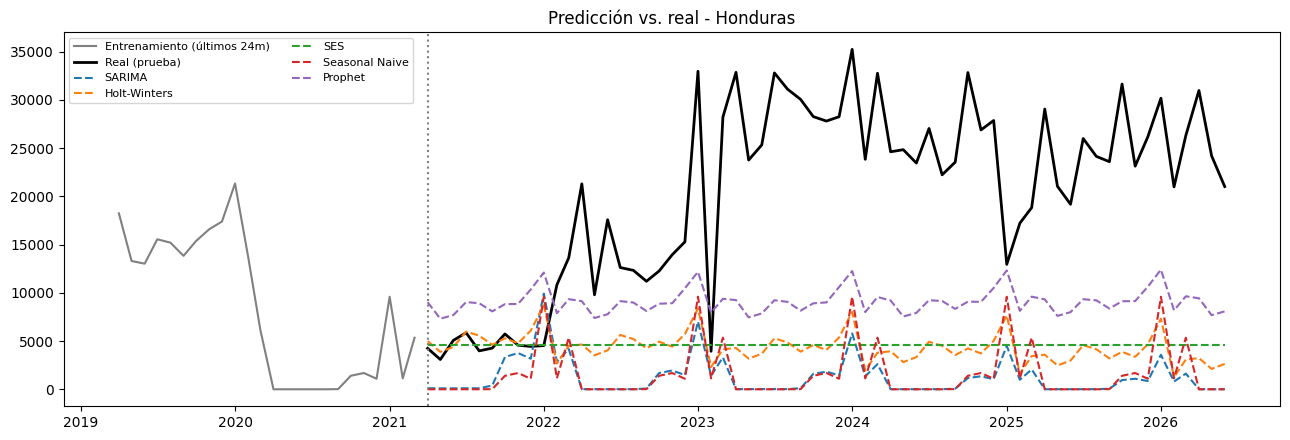

In [53]:
for p in paises_top3:
    fig, ax = plt.subplots(figsize=(13,4.5))
    ax.plot(series_train[p].iloc[-24:], color='gray', label='Entrenamiento (últimos 24m)')
    ax.plot(series_test[p], color='black', linewidth=2, label='Real (prueba)')
    colores = {'SARIMA':'tab:blue', 'Holt-Winters':'tab:orange', 'SES':'tab:green',
               'Seasonal Naive':'tab:red', 'Prophet':'tab:purple'}
    for modelo, color in colores.items():
        ax.plot(predicciones[p][modelo], linestyle='--', color=color, label=modelo)
    ax.axvline(series_test[p].index.min(), color='gray', linestyle=':')
    ax.set_title(f'Predicción vs. real - {p}')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


## 13. Comparación de modelos: MAE, RMSE, AIC y BIC


In [54]:
df_resultados = pd.DataFrame(tabla_general)
for p in paises_top3:
    print("="*80)
    print(p)
    print(df_resultados[df_resultados['País']==p].sort_values('MAE').to_string(index=False))


El Salvador
       País                    Modelo      MAE      RMSE     AIC     BIC
El Salvador                   Prophet 52,289.3  58,497.8     NaN     NaN
El Salvador Suavizamiento Exp. Simple 83,957.1  95,448.7 2,871.5 2,877.5
El Salvador              Holt-Winters 91,215.3 102,022.8 2,836.0 2,883.9
El Salvador            Seasonal Naive 91,662.1 102,198.5     NaN     NaN
El Salvador   SARIMA(1,1,1)(1,1,1)_12 95,234.3 105,762.8   429.1   443.6
Estados Unidos de América
                     País                    Modelo      MAE     RMSE     AIC     BIC
Estados Unidos de América                   Prophet 30,361.7 34,043.7     NaN     NaN
Estados Unidos de América Suavizamiento Exp. Simple 32,289.1 36,162.4 2,686.2 2,692.2
Estados Unidos de América   SARIMA(1,1,1)(1,1,1)_12 35,075.9 38,990.3   409.1   423.6
Estados Unidos de América            Seasonal Naive 40,733.3 43,733.4     NaN     NaN
Estados Unidos de América              Holt-Winters 42,771.7 47,017.0 2,512.5 2,560.3
Honduras

## 14. Selección del mejor modelo por país


In [55]:
mejor_por_pais = df_resultados.loc[df_resultados.groupby('País')['MAE'].idxmin()]
mejor_por_pais[['País','Modelo','MAE','RMSE']]


,País,Modelo,MAE,RMSE
4,El Salvador,Prophet,"52,289.3","58,497.8"
9,Estados Unidos de América,Prophet,"30,361.7","34,043.7"
14,Honduras,Prophet,"12,688.6","14,521.4"


**Conclusión de la comparación de modelos:**

- **Prophet resulta el mejor modelo (menor MAE y RMSE) para las tres series** de "País de
  Residencia" (El Salvador, Estados Unidos de América y Honduras) al evaluarlo contra el conjunto
  de prueba.
- El modelo **SARIMA(1,1,1)(1,1,1)<sub>12</sub>**, a pesar de tener el mejor **AIC/BIC dentro de la
  muestra de entrenamiento**, **no es el que mejor generaliza** al pronosticar un
  horizonte tan largo (63 meses ≈ 5.25 años). Esto ilustra un punto importante: un buen ajuste
  dentro de la muestra (AIC/BIC) no garantiza una buena capacidad predictiva fuera de la muestra,
  especialmente en horizontes largos que abarcan un cambio estructural como la pandemia y su
  recuperación. Con doble diferenciación (regular + estacional) el modelo SARIMA pierde la
  capacidad de extrapolar la tendencia de largo plazo y su incertidumbre crece rápidamente mes a
  mes.
- **Holt-Winters** y el **suavizamiento exponencial simple** ofrecen resultados razonables y
  superan a **Seasonal Naive**, pero no capturan tan bien el quiebre y la posterior recuperación
  pronunciada como Prophet, que incorpora de forma más flexible los cambios de tendencia
  ("changepoints").
- **Modelo final recomendado por país:** Prophet, para El Salvador, Estados Unidos de América y
  Honduras.


## 15. Análisis comparativo entre los tres países

Para responder de forma cuantitativa cuál serie presenta mayor estacionalidad, tendencia,
volatilidad y afectación por la pandemia, se usa la serie histórica completa (entrenamiento +
prueba) y se calculan:

- **Fuerza de estacionalidad / tendencia** (medida de Hyndman, basada en la descomposición
  aditiva): `1 - Var(residuo) / Var(residuo + componente)`, un valor cercano a 1 indica que el
  componente explica casi toda la variabilidad restante.
- **Volatilidad**: coeficiente de variación (desviación estándar / media) de la serie completa.
- **Efecto de la pandemia**: variación porcentual del promedio anual 2020 vs. 2019.


In [56]:
metricas_comparativas = []
for p in paises_top3:
    serie_completa = pd.concat([series_train[p], series_test[p]]).sort_index()
    decomp = seasonal_decompose(serie_completa, model='additive', period=12)
    resid = decomp.resid.dropna()
    seasonal = decomp.seasonal.loc[resid.index]
    trend = decomp.trend.loc[resid.index]

    fuerza_estacional = max(0, 1 - np.var(resid) / np.var(resid + seasonal))
    fuerza_tendencia = max(0, 1 - np.var(resid) / np.var(resid + (trend - trend.mean())))
    cv = serie_completa.std() / serie_completa.mean()

    anual = serie_completa.groupby(serie_completa.index.year).mean()
    pre, pandemia, post = anual.get(2019), anual.get(2020), anual.get(2024)
    caida_pandemia = (pandemia/pre - 1) * 100
    recuperacion_2024 = (post/pre - 1) * 100 if post is not None else np.nan

    metricas_comparativas.append({
        'País': p,
        'Fuerza estacional': round(fuerza_estacional, 3),
        'Fuerza de tendencia': round(fuerza_tendencia, 3),
        'Volatilidad (CV)': round(cv, 3),
        'Caída 2020 vs 2019 (%)': round(caida_pandemia, 1),
        'Var. 2024 vs 2019 (%)': round(recuperacion_2024, 1),
    })

df_comparativo = pd.DataFrame(metricas_comparativas).set_index('País')
df_comparativo


,Fuerza estacional,Fuerza de tendencia,Volatilidad (CV),Caída 2020 vs 2019 (%),Var. 2024 vs 2019 (%)
País,,,,,
El Salvador,0.4,0.9,0.6,-79.8,34.6
Estados Unidos de América,0.7,0.9,0.5,-74.0,43.2
Honduras,0.2,0.9,0.7,-75.5,75.6


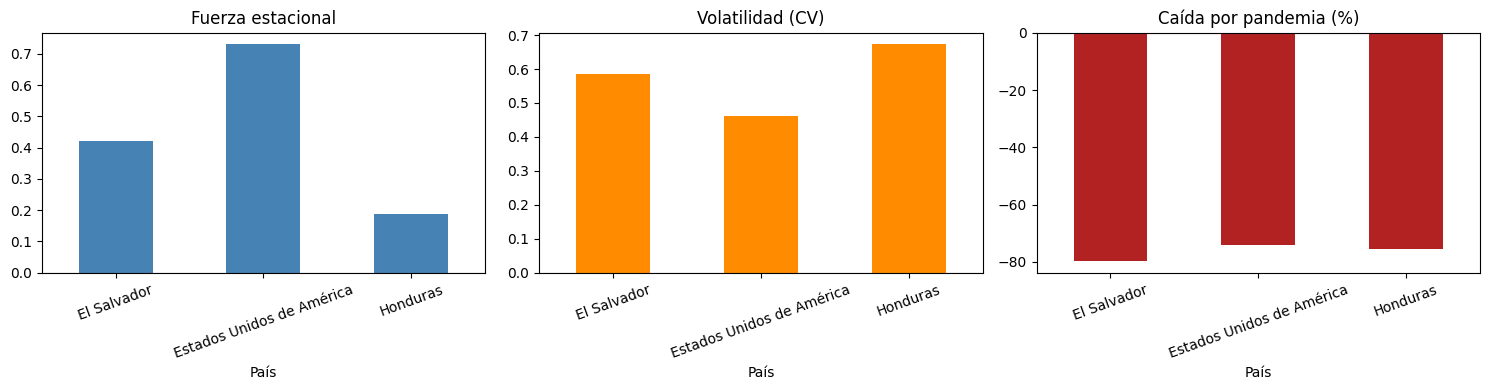

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
df_comparativo['Fuerza estacional'].plot(kind='bar', ax=axes[0], color='steelblue', title='Fuerza estacional')
df_comparativo['Volatilidad (CV)'].plot(kind='bar', ax=axes[1], color='darkorange', title='Volatilidad (CV)')
df_comparativo['Caída 2020 vs 2019 (%)'].plot(kind='bar', ax=axes[2], color='firebrick', title='Caída por pandemia (%)')
for ax in axes:
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
